<a href="https://colab.research.google.com/github/AyubUmair/ComputerVision/blob/main/EN3160.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install opencv-python

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

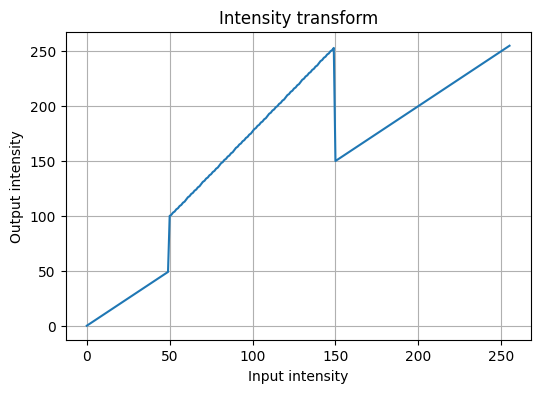

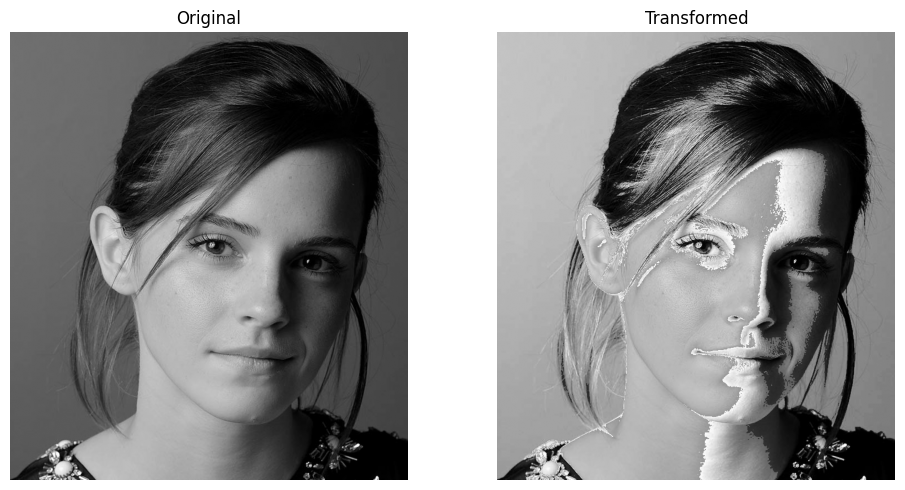

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

breakouts = np.array([[0, 0], [50, 50], [50, 100], [150, 255], [150,150],[255, 255]])
x, y = breakouts[:, 0], breakouts[:, 1]

lut = np.interp(np.arange(256), x, y).astype(np.uint8)
output = cv.LUT(image, lut)

plt.figure(figsize=(6, 4))
plt.plot(lut)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity transform')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(output, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_660/650395624.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(brain.ravel(), 256, [0,256]); plt.title('Brain histogram'); plt.show()


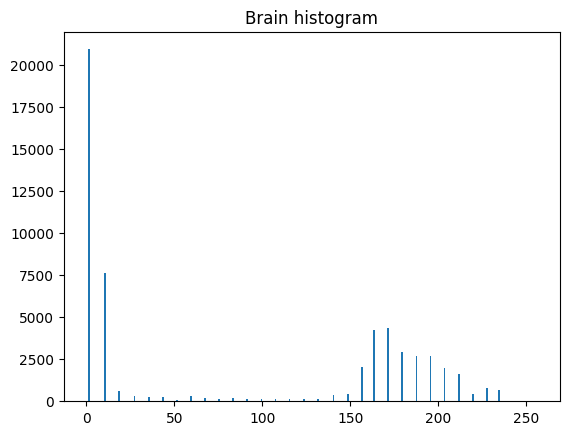

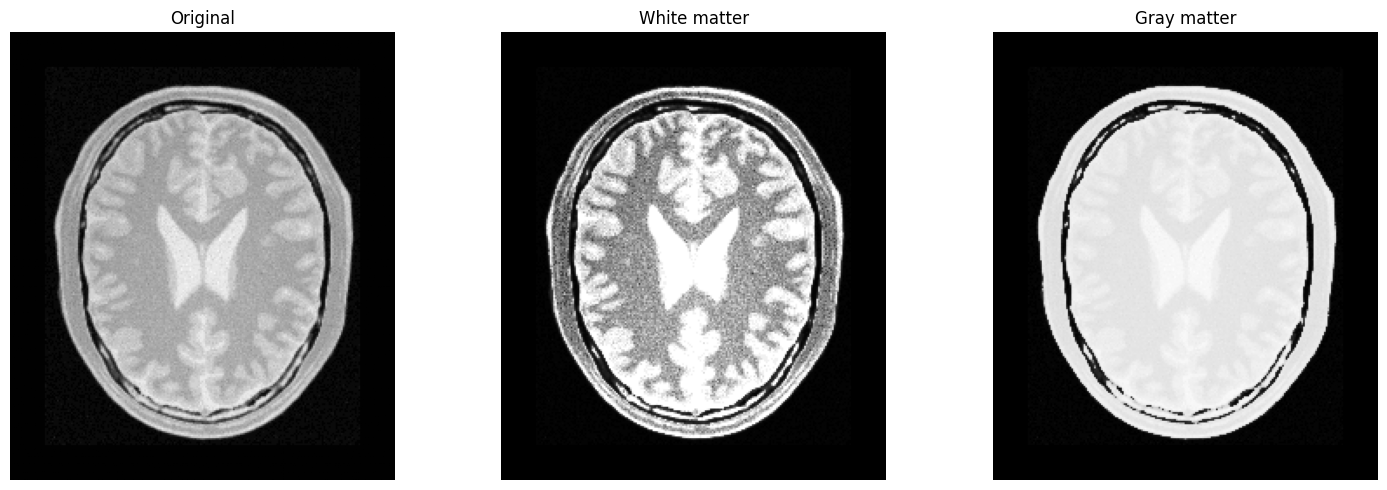

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints)
    x, y = breakpoints[:,0], breakpoints[:,1]
    lut = np.interp(np.arange(256), x, y).astype(np.uint8)
    return cv.LUT(im, lut), lut

brain = cv.imread('BrainProtonDensity.png', cv.IMREAD_GRAYSCALE)
plt.hist(brain.ravel(), 256, [0,256]); plt.title('Brain histogram'); plt.show()


white_matter_bp = [[0,0],[140,60],[180,200],[200,255],[255,255]]
gray_matter_bp  = [[0,0],[90,50],[110,200],[140,220],[255,255]]

white_out, white_lut = intensity_transform(brain, white_matter_bp)
gray_out,  gray_lut  = intensity_transform(brain, gray_matter_bp)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')


axes[1].imshow(white_out, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('White matter')
axes[1].axis('off')


axes[2].imshow(gray_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gray matter')
axes[2].axis('off')

plt.tight_layout()
plt.show()

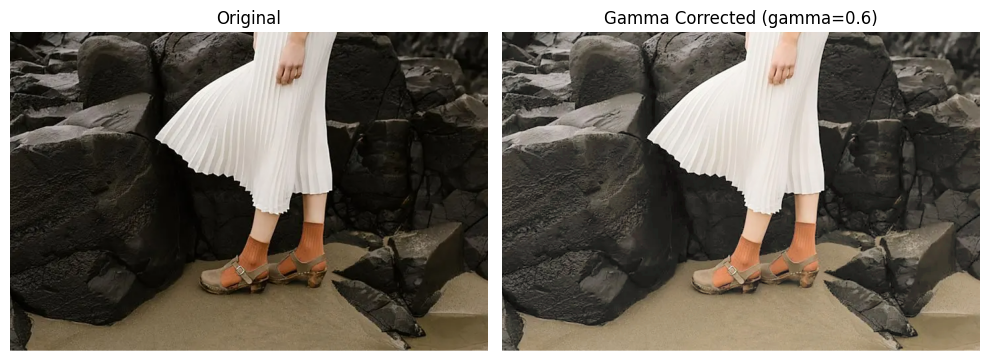

/tmp/ipykernel_4581/1972000234.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax_hist[0].hist(L.ravel(), 256, [0, 256])
/tmp/ipykernel_4581/1972000234.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax_hist[1].hist(L_corrected.ravel(), 256, [0, 256])


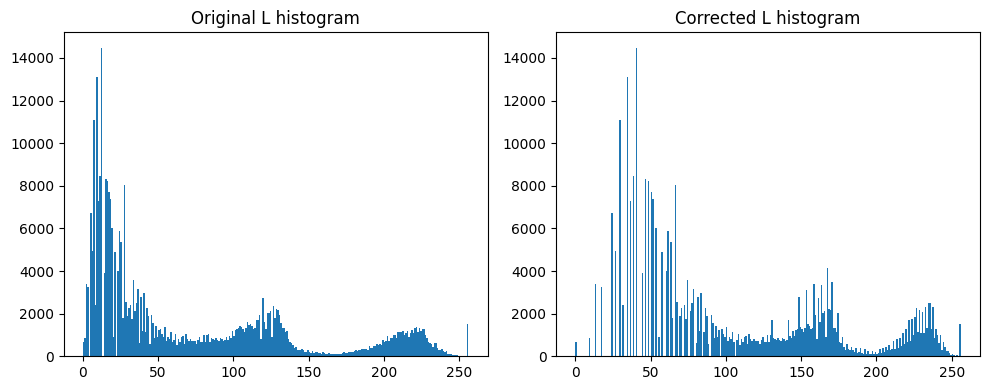

In [14]:
img = cv.imread('Image for gamma correction.png')

if img is None:
    print("Error: Could not load image. Please check the file name.")
else:

    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)


    gamma = 0.6   # <1 brightens shadows, >1 darkens/increases contrast
    L_norm = L / 255.0
    L_corrected = np.power(L_norm, gamma) * 255.0
    L_corrected = L_corrected.astype(np.uint8)


    lab_corrected = cv.merge([L_corrected, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)


    fig_img, ax_img = plt.subplots(1, 2, figsize=(10, 5))


    ax_img[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax_img[0].set_title('Original')
    ax_img[0].axis('off')


    ax_img[1].imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
    ax_img[1].set_title(f'Gamma Corrected (gamma={gamma})')
    ax_img[1].axis('off')

    plt.tight_layout()
    plt.show()

    # --- Display Histograms ---
    fig_hist, ax_hist = plt.subplots(1, 2, figsize=(10, 4))

    ax_hist[0].hist(L.ravel(), 256, [0, 256])
    ax_hist[0].set_title('Original L histogram')

    ax_hist[1].hist(L_corrected.ravel(), 256, [0, 256])
    ax_hist[1].set_title('Corrected L histogram')

    plt.tight_layout()
    plt.show()

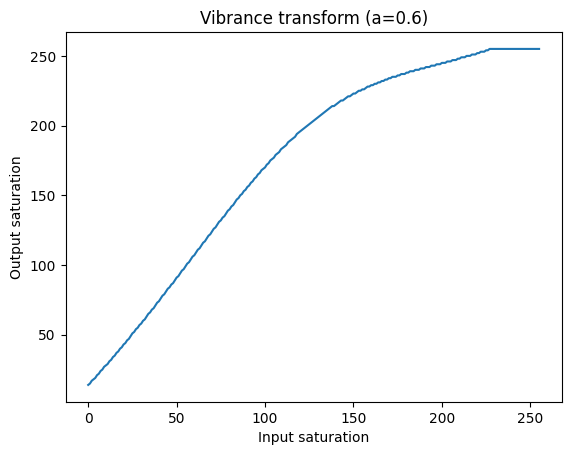

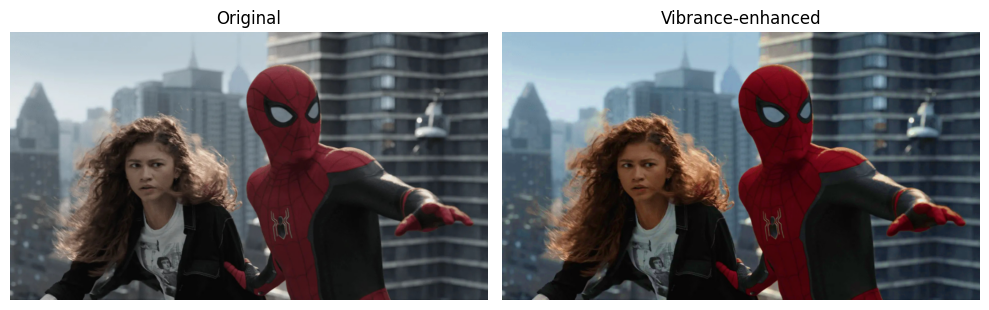

In [6]:
img = cv.imread('Image for enhancing the vibrance.jpg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

def vibrance_lut(a, sigma=70):
    x = np.arange(256)
    f = x + a * 128 * np.exp(-((x-128)**2)/(2*sigma**2))
    return np.clip(f, 0, 255).astype(np.uint8)

a = 0.6
lut = vibrance_lut(a)
s_new = cv.LUT(s, lut)

hsv_new = cv.merge([h, s_new, v])
img_new = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

plt.plot(lut); plt.xlabel('Input saturation'); plt.ylabel('Output saturation')
plt.title(f'Vibrance transform (a={a})'); plt.show()


fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')


axes[1].imshow(cv.cvtColor(img_new, cv.COLOR_BGR2RGB))
axes[1].set_title('Vibrance-enhanced')
axes[1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_660/1118066963.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[0].hist(leaves.ravel(), 256, [0,256]); ax[0].set_title('Before')
/tmp/ipykernel_660/1118066963.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[1].hist(eq.ravel(), 256, [0,256]); ax[1].set_title('After')


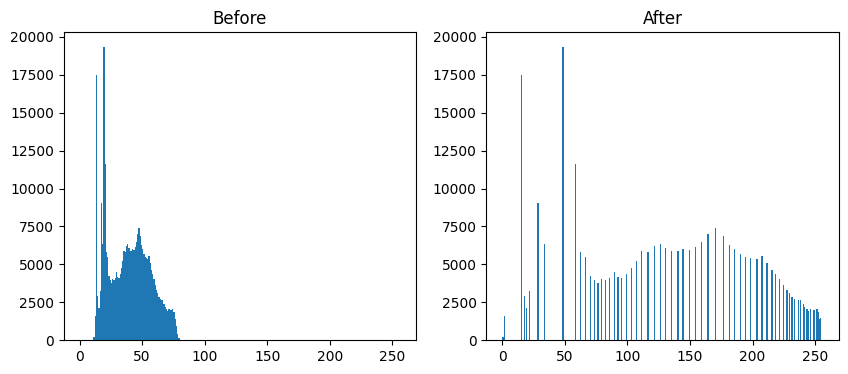

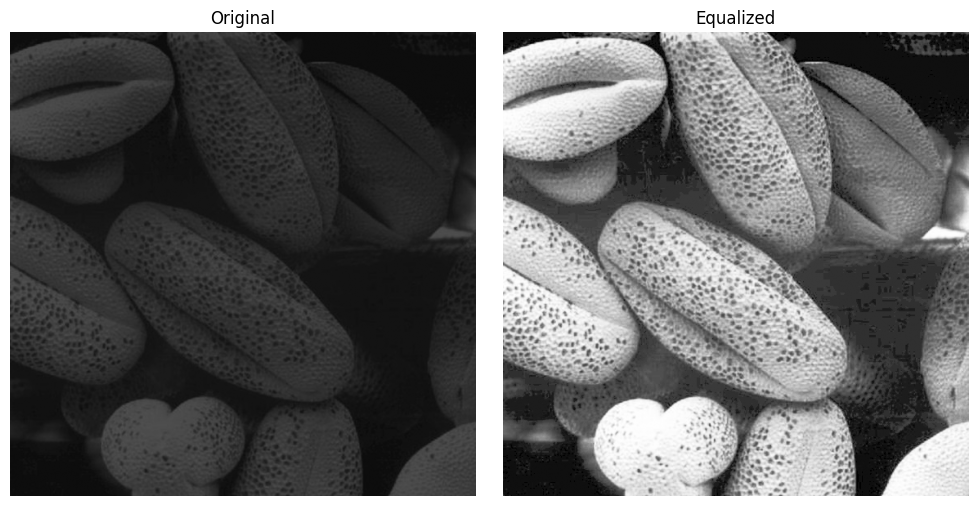

In [7]:
def hist_equalize(im):
    hist, _ = np.histogram(im.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_scaled = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_scaled, 0).astype(np.uint8)
    return lut[im], lut

leaves = cv.imread('fig 5.jpg', cv.IMREAD_GRAYSCALE)
eq, lut = hist_equalize(leaves)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(leaves.ravel(), 256, [0,256]); ax[0].set_title('Before')
ax[1].hist(eq.ravel(), 256, [0,256]); ax[1].set_title('After')
plt.show()


fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))


axes2[0].imshow(leaves, cmap='gray', vmin=0, vmax=255)
axes2[0].set_title('Original')
axes2[0].axis('off')


axes2[1].imshow(eq, cmap='gray', vmin=0, vmax=255)
axes2[1].set_title('Equalized')
axes2[1].axis('off')

plt.tight_layout()
plt.show()

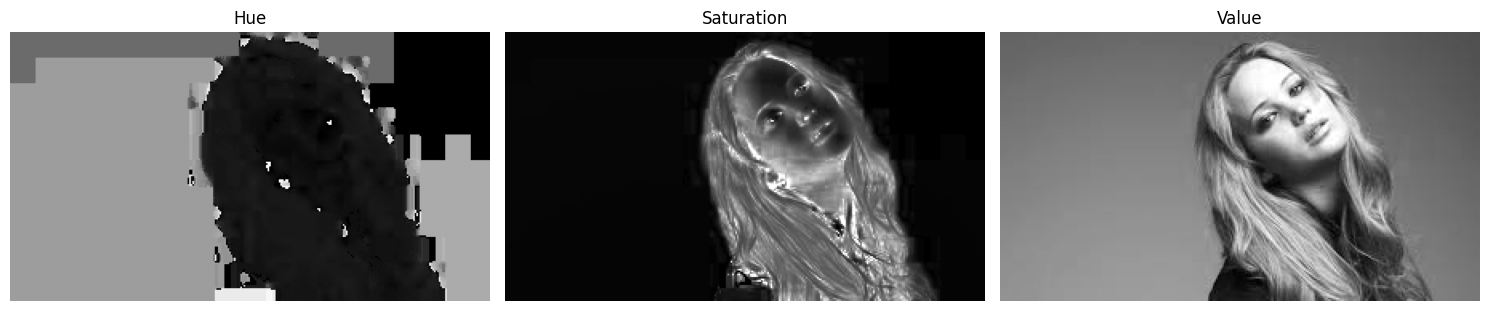

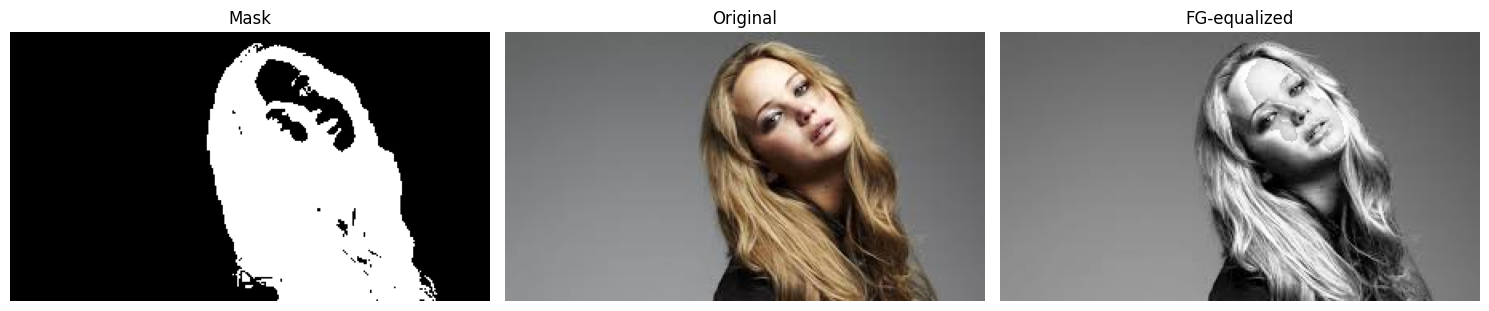

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 6.jpg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)


fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
axes1[0].imshow(h, cmap='gray')
axes1[0].set_title('Hue')
axes1[0].axis('off')
axes1[1].imshow(s, cmap='gray')
axes1[1].set_title('Saturation')
axes1[1].axis('off')
axes1[2].imshow(v, cmap='gray')
axes1[2].set_title('Value')
axes1[2].axis('off')
plt.tight_layout()
plt.show()


_, mask = cv.threshold(s, 60, 255, cv.THRESH_BINARY)   # tune threshold by inspecting histogram
mask_inv = cv.bitwise_not(mask)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
fg = cv.bitwise_and(gray, gray, mask=mask)
bg = cv.bitwise_and(gray, gray, mask=mask_inv)


hist = cv.calcHist([fg], [0], mask, [256], [0,256]).flatten()
cdf = hist.cumsum()
cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_scaled = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
lut = np.ma.filled(cdf_scaled, 0).astype(np.uint8)

fg_eq = lut[gray]
fg_eq = cv.bitwise_and(fg_eq, fg_eq, mask=mask)


result = cv.add(bg, fg_eq)


fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
axes2[0].imshow(mask, cmap='gray')
axes2[0].set_title('Mask')
axes2[0].axis('off')
axes2[1].imshow(img[...,::-1]) # cmap='gray' is ignored for RGB images, so it is omitted here
axes2[1].set_title('Original')
axes2[1].axis('off')
axes2[2].imshow(result, cmap='gray')
axes2[2].set_title('FG-equalized')
axes2[2].axis('off')
plt.tight_layout()
plt.show()

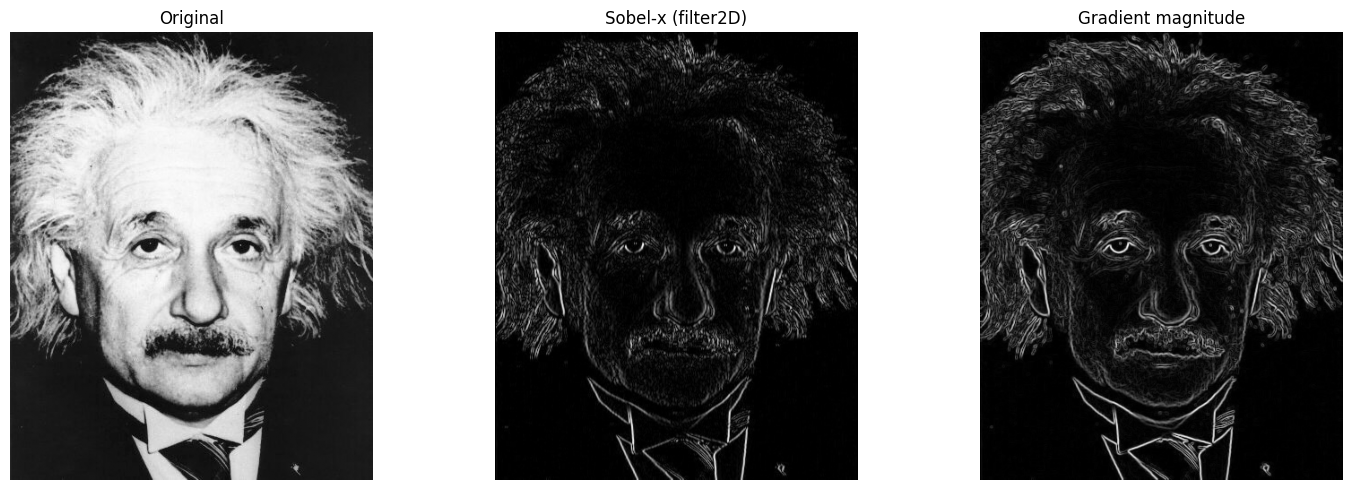

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 7.jpg', cv.IMREAD_GRAYSCALE)

# (a) built-in filter2D
kx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
ky = kx.T
gx_a = cv.filter2D(img.astype(np.float32), -1, kx)
gy_a = cv.filter2D(img.astype(np.float32), -1, ky)

# (b) manual convolution (no filter2D)
def sobel_manual(im, kernel):
    im = im.astype(np.float32)
    padded = np.pad(im, 1, mode='edge')
    out = np.zeros_like(im)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+3, j:j+3]
            out[i,j] = np.sum(region * kernel)
    return out

gx_b = sobel_manual(img, kx)

# (c) separable convolution: [1 2 1]^T * [1 0 -1]
smooth = np.array([1,2,1], dtype=np.float32).reshape(3,1)
deriv  = np.array([1,0,-1], dtype=np.float32).reshape(1,3)
gx_c = cv.filter2D(cv.filter2D(img.astype(np.float32), -1, smooth), -1, deriv)

grad_mag = np.sqrt(gx_a**2 + gy_a**2)

# --- Corrected display code replacing the show() function ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(np.abs(gx_a), cmap='gray')
axes[1].set_title('Sobel-x (filter2D)')
axes[1].axis('off')

axes[2].imshow(grad_mag, cmap='gray')
axes[2].set_title('Gradient magnitude')
axes[2].axis('off')

plt.tight_layout()
plt.show()

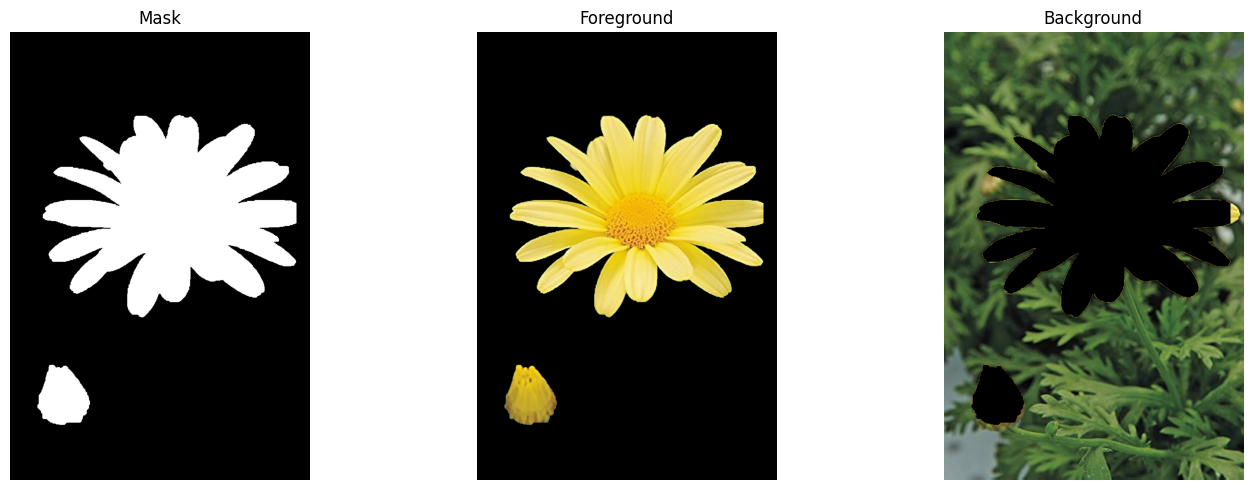

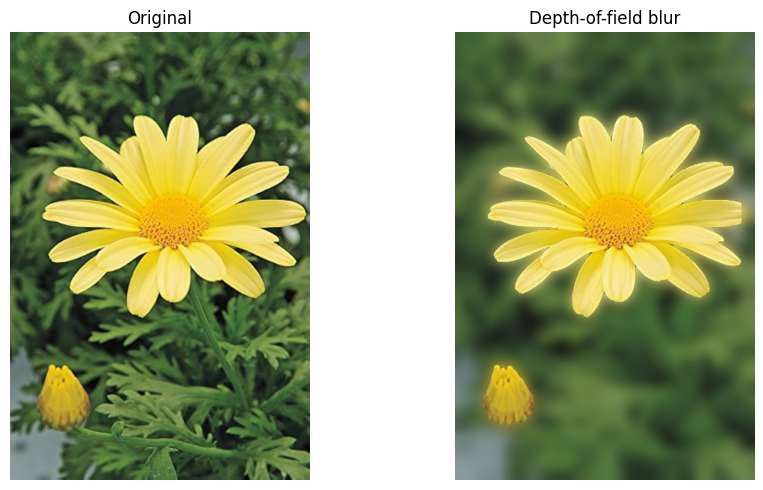

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 8.jpg')
mask = np.zeros(img.shape[:2], np.uint8)
bgd, fgd = np.zeros((1,65), np.float64), np.zeros((1,65), np.float64)

rect = (30, 30, img.shape[1]-60, img.shape[0]-60)
cv.grabCut(img, mask, rect, bgd, fgd, 5, cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
fg = img * mask2[:,:,None]
bg = img * (1-mask2[:,:,None])

blurred_bg = cv.GaussianBlur(img, (0,0), sigmaX=15)
enhanced = fg + blurred_bg * (1-mask2[:,:,None])


fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))

axes1[0].imshow(mask2 * 255, cmap='gray')
axes1[0].set_title('Mask')
axes1[0].axis('off')

axes1[1].imshow(cv.cvtColor(fg, cv.COLOR_BGR2RGB))
axes1[1].set_title('Foreground')
axes1[1].axis('off')

axes1[2].imshow(cv.cvtColor(bg, cv.COLOR_BGR2RGB))
axes1[2].set_title('Background')
axes1[2].axis('off')

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes2[0].set_title('Original')
axes2[0].axis('off')

axes2[1].imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
axes2[1].set_title('Depth-of-field blur')
axes2[1].axis('off')

plt.tight_layout()
plt.show()

SSD (mine vs cv): 28.360480147737764


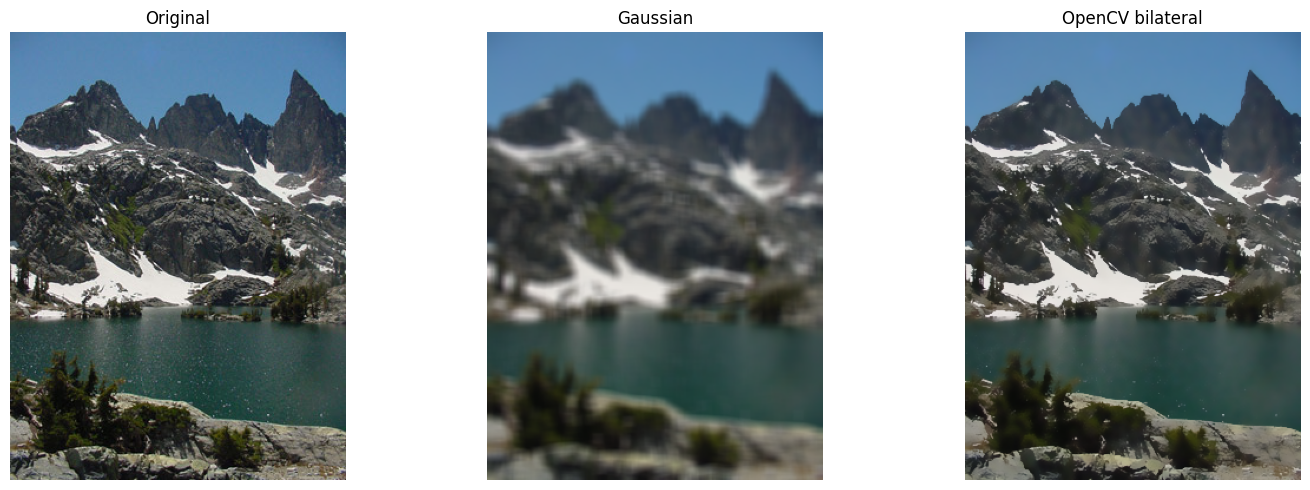

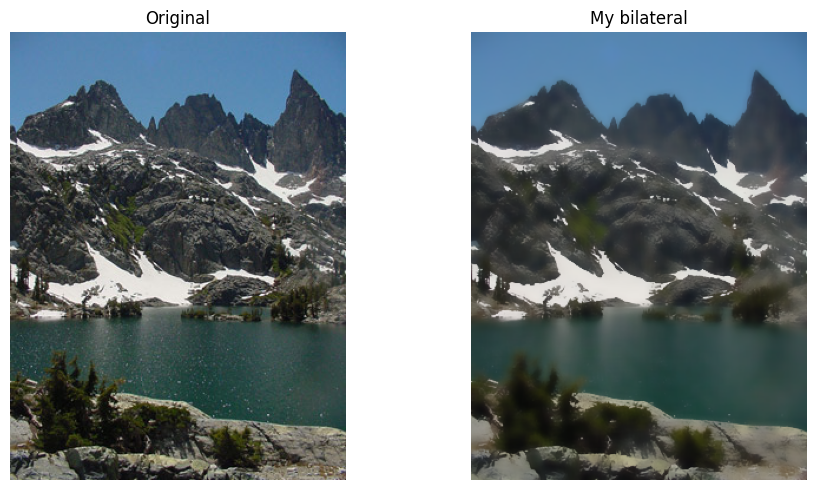

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 9.jpg')
cv_bilateral = cv.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(img, (9,9), sigmaX=75/3)

def bilateral_manual(im, d, sigma_s, sigma_r):
    im = im.astype(np.float64)
    r = d // 2
    padded = np.pad(im, ((r,r),(r,r),(0,0)), mode='edge')
    out = np.zeros_like(im)
    ax = np.arange(-r, r+1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2+yy**2)/(2*sigma_s**2))
    H, W, C = im.shape
    for i in range(H):
        for j in range(W):
            window = padded[i:i+d, j:j+d]
            center = padded[i+r, j+r]
            diff = window - center
            range_w = np.exp(-np.sum(diff**2, axis=2)/(2*sigma_r**2))
            weight = spatial * range_w
            weight /= weight.sum()
            out[i,j] = np.sum(window * weight[:,:,None], axis=(0,1))
    return out.astype(np.uint8)

my_bilateral = bilateral_manual(img, d=9, sigma_s=25, sigma_r=75)

def ssd_normalized(a,b):
    a,b = a.astype(np.float64), b.astype(np.float64)
    return np.sum((a-b)**2)/a.size

print('SSD (mine vs cv):', ssd_normalized(my_bilateral, cv_bilateral))


fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))

axes1[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes1[0].set_title('Original')
axes1[0].axis('off')

axes1[1].imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB))
axes1[1].set_title('Gaussian')
axes1[1].axis('off')

axes1[2].imshow(cv.cvtColor(cv_bilateral, cv.COLOR_BGR2RGB))
axes1[2].set_title('OpenCV bilateral')
axes1[2].axis('off')

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes2[0].set_title('Original')
axes2[0].axis('off')

axes2[1].imshow(cv.cvtColor(my_bilateral, cv.COLOR_BGR2RGB))
axes2[1].set_title('My bilateral')
axes2[1].axis('off')

plt.tight_layout()
plt.show()